# Southend Pier -- Initial Tide-Level Modelling (PyTorch)

First-pass neural forecasting baselines on the cleaned Southend Pier gauge record, predicting the observed water level (`Observed_ODN`, referenced to Ordnance Datum Newlyn) purely from its own recent history -- no harmonic or meteorological covariates yet.

**Data**: `3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv` -- 10-minute readings, 2004-2024, with the chatter and stuck-sensor faults already patched (see `EDA/southend_pier_data_cleaning_summary.md`).

**Task**: given the last 16h of readings (96 steps), predict the next 10-minute value. Persistence and a naive tidal-lag baseline are carried through the whole notebook for context, since a 10-minute-ahead target is easy to get "right" by just echoing the last observation -- the baselines are what make the neural nets' numbers meaningful.

**Split**: chronological, non-overlapping -- train 2004-2017, validation 2018-2020, test 2021-2024. The scaler and all models are fit on train only; validation drives early stopping/model selection; test is touched once at the end.

**Models**: MLP, vanilla RNN, LSTM -- small, single-feature, PyTorch.

**Runtime**: tuned to run comfortably on a laptop CPU (no NVIDIA GPU needed at this scale) -- on an 8-core laptop, MLP trains in a few minutes and RNN/LSTM in roughly 10-30 minutes total with the settings below (`LOOKBACK=96`, training windows subsampled to a 30-min stride). If you do have a CUDA GPU or a Colab runtime handy, it'll auto-detect and use it, and you can push `LOOKBACK` back up to see more history per prediction.


In [22]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


## 1. Setup


In [23]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"BF16 supported:  {torch.cuda.is_bf16_supported()}")
else:
    print("No GPU detected -- running on CPU. That's fine at this notebook's scale (see intro); "
          "LOOKBACK and TRAIN_STRIDE below are chosen to keep CPU training fast.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
LOOKBACK = 96       # 16h of 10-minute steps (>1 full semi-diurnal cycle). Raise this (e.g. 288 = 48h)
                    # if running on a GPU -- RNN/LSTM cost scales with LOOKBACK, and 288 takes hours on CPU.
TRAIN_STRIDE = 3    # only start a new training window every 3rd step (30 min) to cut epoch time on CPU;
                    # validation/test stay at full 10-min resolution so reported metrics aren't affected.
BATCH_SIZE = 1024
EPOCHS = 60
PATIENCE = 10
LR = 1e-3
TRAIN_END = '2018-01-01'
VAL_END = '2021-01-01'

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
torch.backends.cudnn.benchmark = True


PyTorch version: 2.10.0+cu128
CUDA available:  True
GPU:             NVIDIA A100-SXM4-80GB
BF16 supported:  True


In [24]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/tidal_analysis_and_prediction/10_SOUTHEND_chatter_and_stuck_patched.csv'  # <-- edit if your file lives elsewhere
else:
    DATA_PATH = '../3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv'

assert os.path.exists(DATA_PATH), f"Can't find data at {DATA_PATH} -- update DATA_PATH above."


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load & inspect data


In [25]:
usecols = ['DateTime', 'Observed_ODN', 'is_chatter_flagged', 'is_stuck_flagged', 'is_imputed']
df = pd.read_csv(DATA_PATH, usecols=usecols, parse_dates=['DateTime'])
df = df.sort_values('DateTime').reset_index(drop=True)
df['is_flagged'] = df['is_chatter_flagged'] | df['is_stuck_flagged'] | df['is_imputed']

STEP = pd.Timedelta('10min')
gap_mask = df['DateTime'].diff() > STEP

print(f"{len(df):,} rows, {df.DateTime.min()} to {df.DateTime.max()}")
print(f"{gap_mask.sum()} gaps > 10min ({gap_mask.sum() + 1} contiguous segments)")
print(f"Flagged (chatter/stuck/imputed) points: {df['is_flagged'].sum():,} ({100 * df['is_flagged'].mean():.3f}%)")
df.head()


1,103,956 rows, 2004-01-01 00:00:00 to 2024-12-31 23:50:00
90 gaps > 10min (91 contiguous segments)
Flagged (chatter/stuck/imputed) points: 9,975 (0.904%)


,DateTime,is_imputed,Observed_ODN,is_chatter_flagged,is_stuck_flagged,is_flagged
0,2004-01-01 00:00:00,False,-1.819,False,False,False
1,2004-01-01 00:10:00,False,-1.855,False,False,False
2,2004-01-01 00:20:00,False,-1.874,False,False,False
3,2004-01-01 00:30:00,False,-1.895,False,False,False
4,2004-01-01 00:40:00,False,-1.904,False,False,False


## 3. Chronological train / validation / test split

Split the raw series into three non-overlapping calendar-year blocks *before* windowing, so no input window ever reaches across a split boundary. Because the chatter/stuck faults were almost all pre-2016, validation and test come out nearly fault-free on their own.


In [26]:
train_df = df[df['DateTime'] < TRAIN_END].reset_index(drop=True)
val_df = df[(df['DateTime'] >= TRAIN_END) & (df['DateTime'] < VAL_END)].reset_index(drop=True)
test_df = df[df['DateTime'] >= VAL_END].reset_index(drop=True)

for split_name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"{split_name:5s}: {len(split):>8,} rows  [{split.DateTime.min()} -> {split.DateTime.max()}]  "
          f"flagged={100 * split['is_flagged'].mean():.3f}%")


train:  735,760 rows  [2004-01-01 00:00:00 -> 2017-12-31 23:50:00]  flagged=1.338%
val  :  157,824 rows  [2018-01-01 00:00:00 -> 2020-12-31 23:50:00]  flagged=0.038%
test :  210,372 rows  [2021-01-01 00:00:00 -> 2024-12-31 23:50:00]  flagged=0.032%


## 4. Windowing

Build sliding windows of `LOOKBACK` past values -> next value, independently within each split and within each gap-free segment of that split (so a window never bridges a sensor gap or a split boundary). Training windows are then subsampled by `TRAIN_STRIDE` to cut CPU training time -- consecutive windows overlap almost entirely anyway, so this loses little; validation and test are left at full resolution since they're only ever run forward (no backprop), which is cheap regardless.


In [27]:
def build_windows(sub_df, lookback=LOOKBACK):
    sub_df = sub_df.reset_index(drop=True)
    is_gap = sub_df['DateTime'].diff() > STEP
    seg_id = is_gap.cumsum().to_numpy()

    values = sub_df['Observed_ODN'].to_numpy(dtype=np.float32)
    flagged = sub_df['is_flagged'].to_numpy()
    times = sub_df['DateTime'].to_numpy()

    X_list, y_list, flag_list, time_list = [], [], [], []
    for seg in np.unique(seg_id):
        idx = np.where(seg_id == seg)[0]
        if len(idx) < lookback + 1:
            continue
        windows = np.lib.stride_tricks.sliding_window_view(values[idx], lookback + 1)
        X_list.append(windows[:, :lookback])
        y_list.append(windows[:, lookback])
        flag_list.append(flagged[idx][lookback:])
        time_list.append(times[idx][lookback:])

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    flag = np.concatenate(flag_list, axis=0)
    time = np.concatenate(time_list, axis=0)
    return X, y, flag, time


In [28]:
X_train, y_train, flag_train, time_train = build_windows(train_df)
X_val, y_val, flag_val, time_val = build_windows(val_df)
X_test, y_test, flag_test, time_test = build_windows(test_df)

X_train, y_train, flag_train, time_train = (
    X_train[::TRAIN_STRIDE], y_train[::TRAIN_STRIDE], flag_train[::TRAIN_STRIDE], time_train[::TRAIN_STRIDE]
)

print(f"windows -> train: {X_train.shape} (stride {TRAIN_STRIDE}), val: {X_val.shape}, test: {X_test.shape}")


windows -> train: (243001, 96) (stride 3), val: (157728, 96), test: (209389, 96)


## 5. Scaling

Standardise using the train split's mean/std only, then apply the same transform to validation and test -- no statistics leak across the split boundary.


In [29]:
train_mean = float(train_df['Observed_ODN'].mean())
train_std = float(train_df['Observed_ODN'].std())
print(f"train mean={train_mean:.4f} m, std={train_std:.4f} m")

def to_tensor(a):
    return torch.tensor(a, dtype=torch.float32, device=device)

X_train_t = to_tensor((X_train - train_mean) / train_std)
y_train_t = to_tensor((y_train - train_mean) / train_std)
X_val_t = to_tensor((X_val - train_mean) / train_std)
y_val_t = to_tensor((y_val - train_mean) / train_std)
X_test_t = to_tensor((X_test - train_mean) / train_std)

flag_train_t = torch.tensor(flag_train, dtype=torch.bool, device=device)
flag_val_t = torch.tensor(flag_val, dtype=torch.bool, device=device)

train mean=0.1459 m, std=1.5730 m


## 6. Baselines

Persistence (`y(t+1) = y(t)`), computed on the raw (unscaled) windows, masking out flagged/imputed targets -- the number the neural nets need to beat.

In [30]:
def masked_rmse_mae(pred, true, flagged):
    mask = ~flagged
    err = pred[mask] - true[mask]
    return float(np.sqrt(np.mean(err ** 2))), float(np.mean(np.abs(err)))

def persistence_pred(X_raw):
    return X_raw[:, -1]

results = []
for split_name, X_raw, y_raw, flg in [('val', X_val, y_val, flag_val), ('test', X_test, y_test, flag_test)]:
    rmse, mae = masked_rmse_mae(persistence_pred(X_raw), y_raw, flg)
    results.append({'model': 'Persistence', 'split': split_name, 'rmse_m': rmse, 'mae_m': mae})

pd.DataFrame(results).pivot(index='model', columns='split', values=['rmse_m', 'mae_m']).round(4)

rmse_m           mae_m        
split          test     val    test     val
model                                      
Persistence  0.1329  0.1351  0.1181  0.1202

## 6b. UTide harmonic baseline

A third baseline, of a different kind: [UTide](https://github.com/wesleybowman/UTide) fits a fixed set of tidal constituents (amplitude/phase per astronomical frequency) from observed data, then reconstructs the predicted tide at any timestamp -- including ones it never saw. There's no "training" in the neural-net sense and no hyperparameters to tune, so instead of holding out validation data we fit on train+val (2004-2020) and evaluate purely out-of-sample on test (2021-2024), same as `EDA/utide_test.ipynb`'s solve/reconstruct pattern but restricted to a proper fit/eval split. Flagged (chatter/stuck/imputed) points are excluded from the fit since those were themselves filled in via a UTide reconstruction during cleaning -- including them would be circular.

Because UTide only models the deterministic astronomical tide (no meteorological surge), it should comfortably beat `Persistence` but isn't expected to match the trained neural nets, which learn the surge residual too.

In [31]:
import utide

site_lat = 51.5145  # Southend Pier, matches EDA/utide_test.ipynb

# Fit on train+val, excluding flagged (chatter/stuck/imputed) points to avoid
# fitting on UTide's own past reconstruction.
fit_df = pd.concat([train_df, val_df], ignore_index=True)
fit_df.loc[fit_df['is_flagged'], 'Observed_ODN'] = np.nan

coef = utide.solve(fit_df['DateTime'], fit_df['Observed_ODN'],
                    lat=site_lat, method='ols', conf_int='none')

# Reconstruct at the same (windowed) test timestamps/targets used by every
# other model in the results table, for a like-for-like row.
tide_test = utide.reconstruct(pd.DatetimeIndex(time_test), coef, verbose=False)
rmse_u, mae_u = masked_rmse_mae(tide_test.h, y_test, flag_test)
results.append({'model': 'UTide', 'split': 'test', 'rmse_m': rmse_u, 'mae_m': mae_u})

print(f"UTide test: rmse={rmse_u:.4f} m, mae={mae_u:.4f} m")

solve: matrix prep ... solution ... done.
UTide test: rmse=0.2427 m, mae=0.1754 m


## 7. Models

Three small single-feature architectures. Each takes a `(batch, LOOKBACK)` window and returns a `(batch,)` prediction, so they can share one training loop.


In [32]:
class MLP(nn.Module):
    def __init__(self, lookback, hidden=(128, 64)):
        super().__init__()
        dims = [lookback, *hidden]
        layers = []
        for i in range(len(dims) - 1):
            layers += [nn.Linear(dims[i], dims[i + 1]), nn.ReLU()]
        layers.append(nn.Linear(dims[-1], 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


class RNNModel(nn.Module):
    def __init__(self, hidden_size=64, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x.unsqueeze(-1))
        return self.head(out[:, -1, :]).squeeze(-1)


class LSTMModel(nn.Module):
    def __init__(self, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x.unsqueeze(-1))
        return self.head(out[:, -1, :]).squeeze(-1)


## 8. Training utilities

A shared batch iterator -- the data already lives on-GPU at this point, so batching is just indexing and there's no need for a `DataLoader`/worker-process overhead at this data size -- plus a training loop with early stopping on validation loss. Both the train and val loss mask out flagged (chatter/stuck/imputed) targets, so the model is never trained or scored on points that are themselves synthetic UTide-reconstructed fill values from the cleaning pass -- only genuine sensor readings shape the loss.

In [33]:
def batch_iter(X, y, flag, batch_size, shuffle):
    n = X.shape[0]
    idx = torch.randperm(n, device=X.device) if shuffle else torch.arange(n, device=X.device)
    for start in range(0, n, batch_size):
        b = idx[start:start + batch_size]
        yield X[b], y[b], flag[b]


def masked_mse(pred, true, flag_b):
    per_sample = (pred - true) ** 2
    return per_sample[~flag_b].mean()


def train_model(model, X_train, y_train, flag_train, X_val, y_val, flag_val, epochs, batch_size, lr, patience):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    use_amp = device.type == 'cuda'

    best_val = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        running_loss, n_seen = 0.0, 0
        for xb, yb, flag_b in batch_iter(X_train, y_train, flag_train, batch_size, shuffle=True):
            opt.zero_grad()
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                loss = masked_mse(model(xb), yb, flag_b)
            loss.backward()
            opt.step()
            n_valid = int((~flag_b).sum())
            running_loss += loss.item() * n_valid
            n_seen += n_valid
        train_loss = running_loss / n_seen

        model.eval()
        val_loss_sum, n_val = 0.0, 0
        with torch.no_grad():
            for xb, yb, flag_b in batch_iter(X_val, y_val, flag_val, batch_size, shuffle=False):
                with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                    loss = masked_mse(model(xb), yb, flag_b)
                n_valid = int((~flag_b).sum())
                val_loss_sum += loss.item() * n_valid
                n_val += n_valid
        val_loss = val_loss_sum / n_val

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        sched.step(val_loss)

        improved = val_loss < best_val - 1e-6
        if improved:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"  epoch {epoch + 1:03d}  train_loss={train_loss:.5f}  val_loss={val_loss:.5f}"
              f"  lr={opt.param_groups[0]['lr']:.1e}{'  *' if improved else ''}")

        if epochs_no_improve >= patience:
            print(f"  early stopping at epoch {epoch + 1} (best val_loss={best_val:.5f})")
            break

    model.load_state_dict(best_state)
    return model, history


@torch.no_grad()
def compute_metrics(model, X_t, y_raw, flagged, batch_size=8192):
    model.eval()
    preds = []
    for start in range(0, X_t.shape[0], batch_size):
        preds.append(model(X_t[start:start + batch_size]))
    preds_m = torch.cat(preds).cpu().numpy() * train_std + train_mean
    rmse, mae = masked_rmse_mae(preds_m, y_raw, flagged)
    return rmse, mae, preds_m

## 9. Train MLP, RNN, LSTM

Same training loop, same seed reset before each model, so the comparison isn't confounded by different init/shuffle luck.


In [34]:
model_factories = {
    'MLP': lambda: MLP(LOOKBACK),
    'RNN': lambda: RNNModel(hidden_size=64, num_layers=1),
    'LSTM': lambda: LSTMModel(hidden_size=64, num_layers=1),
}

trained = {}
histories = {}
for name, factory in model_factories.items():
    print(f"\n=== Training {name} ===")
    set_seed()
    model = factory().to(device)
    model, history = train_model(
        model, X_train_t, y_train_t, flag_train_t, X_val_t, y_val_t, flag_val_t,
        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    )
    trained[name] = model
    histories[name] = history


=== Training MLP ===
  epoch 001  train_loss=0.03380  val_loss=0.00241  lr=1.0e-03  *
  epoch 002  train_loss=0.00134  val_loss=0.00073  lr=1.0e-03  *
  epoch 003  train_loss=0.00077  val_loss=0.00059  lr=1.0e-03  *
  epoch 004  train_loss=0.00062  val_loss=0.00039  lr=1.0e-03  *
  epoch 005  train_loss=0.00053  val_loss=0.00030  lr=1.0e-03  *
  epoch 006  train_loss=0.00045  val_loss=0.00030  lr=1.0e-03
  epoch 007  train_loss=0.00044  val_loss=0.00036  lr=1.0e-03
  epoch 008  train_loss=0.00040  val_loss=0.00022  lr=1.0e-03  *
  epoch 009  train_loss=0.00040  val_loss=0.00032  lr=1.0e-03
  epoch 010  train_loss=0.00036  val_loss=0.00033  lr=1.0e-03
  epoch 011  train_loss=0.00038  val_loss=0.00021  lr=1.0e-03  *
  epoch 012  train_loss=0.00035  val_loss=0.00018  lr=1.0e-03  *
  epoch 013  train_loss=0.00035  val_loss=0.00022  lr=1.0e-03
  epoch 014  train_loss=0.00033  val_loss=0.00022  lr=1.0e-03
  epoch 015  train_loss=0.00039  val_loss=0.00021  lr=1.0e-03
  epoch 016  train_loss=

## 10. Results

RMSE/MAE in metres on validation and test, flagged/imputed targets excluded, alongside the baselines from section 6.


In [35]:
val_preds, test_preds = {}, {}
for name, model in trained.items():
    rmse_v, mae_v, val_preds[name] = compute_metrics(model, X_val_t, y_val, flag_val)
    rmse_t, mae_t, test_preds[name] = compute_metrics(model, X_test_t, y_test, flag_test)
    results.append({'model': name, 'split': 'val', 'rmse_m': rmse_v, 'mae_m': mae_v})
    results.append({'model': name, 'split': 'test', 'rmse_m': rmse_t, 'mae_m': mae_t})

results_df = pd.DataFrame(results)
results_df.pivot(index='model', columns='split', values=['rmse_m', 'mae_m']).round(4)


rmse_m           mae_m        
split          test     val    test     val
model                                      
LSTM         0.0143  0.0153  0.0093  0.0093
MLP          0.0139  0.0146  0.0089  0.0088
Persistence  0.1329  0.1351  0.1181  0.1202
RNN          0.0129  0.0140  0.0081  0.0081
UTide        0.2427     NaN  0.1754     NaN

## 11. Loss curves


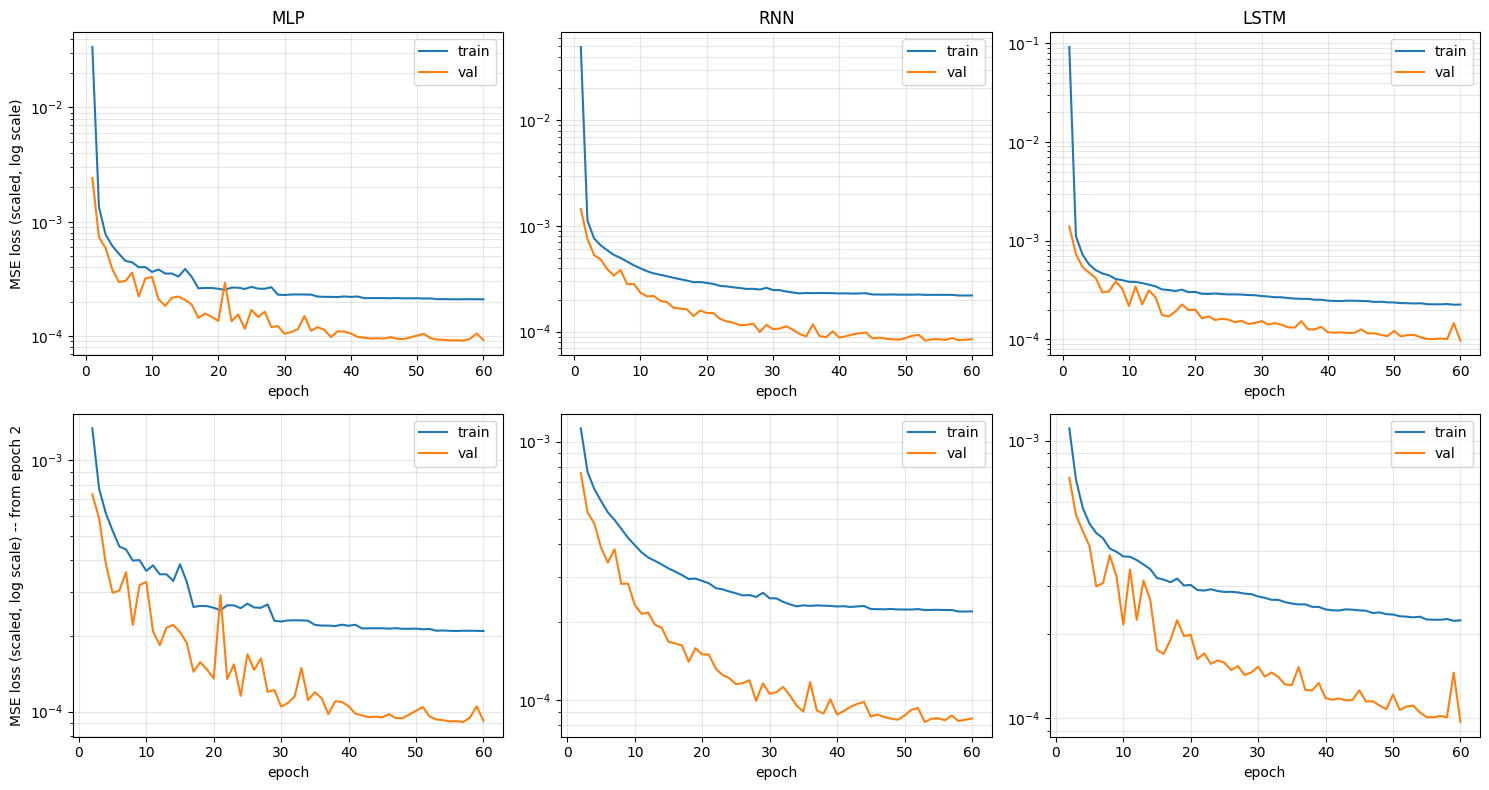

In [36]:
n = len(histories)
fig, axes = plt.subplots(2, n, figsize=(5 * n, 8))
for col, (name, history) in enumerate(histories.items()):
    epochs = np.arange(1, len(history['train_loss']) + 1)
    for row, start_epoch in enumerate([1, 2]):
        ax = axes[row, col]
        mask = epochs >= start_epoch
        ax.plot(epochs[mask], np.array(history['train_loss'])[mask], label='train')
        ax.plot(epochs[mask], np.array(history['val_loss'])[mask], label='val')
        ax.set_yscale('log')
        ax.set_xlabel('epoch')
        ax.legend()
        ax.grid(alpha=0.3, which='both')
    axes[0, col].set_title(name)

axes[0, 0].set_ylabel('MSE loss (scaled, log scale)')
axes[1, 0].set_ylabel('MSE loss (scaled, log scale) -- from epoch 2')
plt.tight_layout()
plt.show()

## 11b. Why is val loss lower than train loss? -- split variance diagnostics

A lower val loss doesn't necessarily mean the model generalises better -- it can just mean val is an *easier* period. Two things matter for one-step MSE specifically:

- The **overall level** (`Observed_ODN` itself) barely matters to a one-step predictor -- it mostly sees a shifted/scaled version of the same tidal cycle regardless of absolute level.
- The **step-to-step change** (`Δ` between consecutive 10-min readings) is what the model actually has to predict the size of. If train contains rougher/noisier periods (sensor faults, storms) than val, train's *irreducible* error is higher no matter how good the fit is.

`train_df` also has ~35x the flagged (chatter/stuck/imputed) rate of `val_df` (1.34% vs 0.04%, from section 3) -- flagged points are exactly the kind of point-to-point roughness that's hard to fit, and they're concentrated almost entirely in train.

In [37]:
splits = {'train': train_df, 'val': val_df, 'test': test_df}
step_diffs = {}

print(f"{'split':6s} {'n':>10s} {'mean_m':>8s} {'std_m':>8s} {'min_m':>8s} {'max_m':>8s} "
      f"{'step_mean_abs':>14s} {'step_std':>10s} {'flagged%':>9s}")
for name, d in splits.items():
    level = d['Observed_ODN']

    # genuine 10-min step, both endpoints unflagged -- diff() on the raw series first so we
    # never treat "one removed/flagged row apart" or "either side of a data gap" as a real step
    is_real_step = (d['DateTime'].diff() == STEP) & ~d['is_flagged'] & ~d['is_flagged'].shift(1, fill_value=True)
    step = d['Observed_ODN'].diff()[is_real_step]
    step_diffs[name] = step

    print(f"{name:6s} {len(d):>10,} {level.mean():>8.4f} {level.std():>8.4f} {level.min():>8.4f} {level.max():>8.4f} "
          f"{step.abs().mean():>14.5f} {step.std():>10.5f} {100 * d['is_flagged'].mean():>8.3f}%")

split           n   mean_m    std_m    min_m    max_m  step_mean_abs   step_std  flagged%
train     735,760   0.1459   1.5730  -3.3940   4.1360        0.11975    0.13476    1.338%
val       157,824   0.2247   1.5869  -2.9320   4.0340        0.12020    0.13489    0.038%
test      210,372   0.2623   1.5638  -2.9000   4.0290        0.11805    0.13279    0.032%


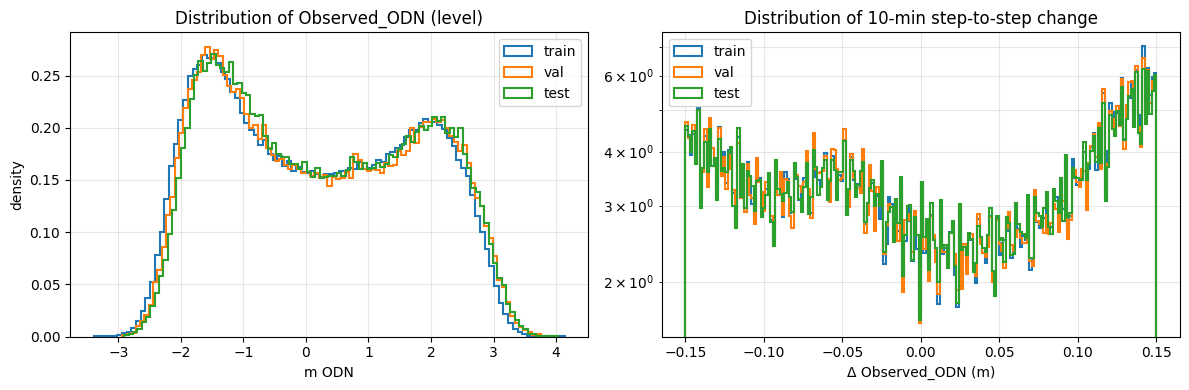

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, d in splits.items():
    axes[0].hist(d['Observed_ODN'], bins=100, histtype='step', density=True, label=name, linewidth=1.5)
axes[0].set_title('Distribution of Observed_ODN (level)')
axes[0].set_xlabel('m ODN')
axes[0].set_ylabel('density')
axes[0].legend()
axes[0].grid(alpha=0.3)

for name, step in step_diffs.items():
    axes[1].hist(step, bins=200, range=(-0.15, 0.15), histtype='step', density=True, label=name, linewidth=1.5)
axes[1].set_title('Distribution of 10-min step-to-step change')
axes[1].set_xlabel('Δ Observed_ODN (m)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

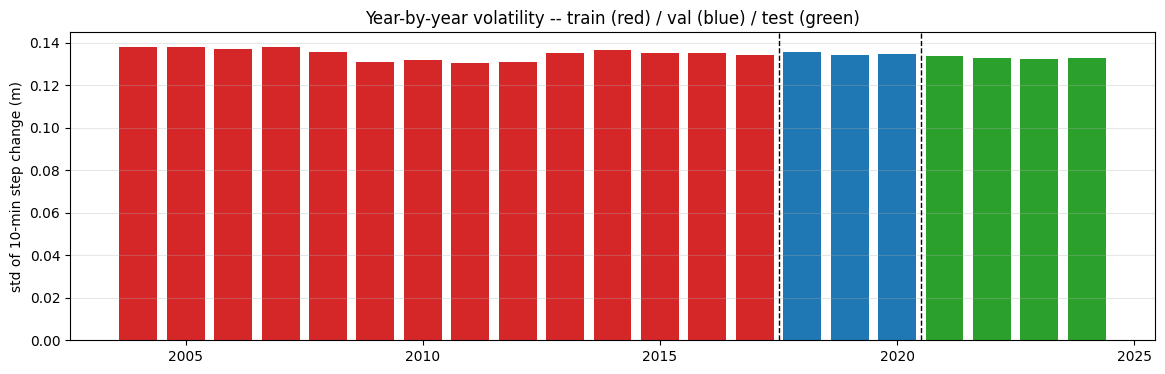

In [39]:
is_real_step_full = (df['DateTime'].diff() == STEP) & ~df['is_flagged'] & ~df['is_flagged'].shift(1, fill_value=True)
full_step = df['Observed_ODN'].diff()[is_real_step_full]
full_year = df.loc[is_real_step_full, 'DateTime'].dt.year

yearly_step_std = full_step.groupby(full_year).std()

train_end_year = pd.Timestamp(TRAIN_END).year
val_end_year = pd.Timestamp(VAL_END).year
split_colors = {'train': '#d62728', 'val': '#1f77b4', 'test': '#2ca02c'}
bar_colors = [
    split_colors['train'] if y < train_end_year else split_colors['val'] if y < val_end_year else split_colors['test']
    for y in yearly_step_std.index
]

plt.figure(figsize=(14, 4))
plt.bar(yearly_step_std.index, yearly_step_std.values, color=bar_colors)
plt.axvline(train_end_year - 0.5, color='k', linestyle='--', linewidth=1)
plt.axvline(val_end_year - 0.5, color='k', linestyle='--', linewidth=1)
plt.ylabel('std of 10-min step change (m)')
plt.title('Year-by-year volatility -- train (red) / val (blue) / test (green)')
plt.grid(alpha=0.3, axis='y')
plt.show()

## 12. Predictions vs. observed -- test set sample

One-step-ahead (10-minute) predictions, so differences from the observed line will be subtle -- that's expected at this horizon. See the rollout section below for how error grows further ahead.


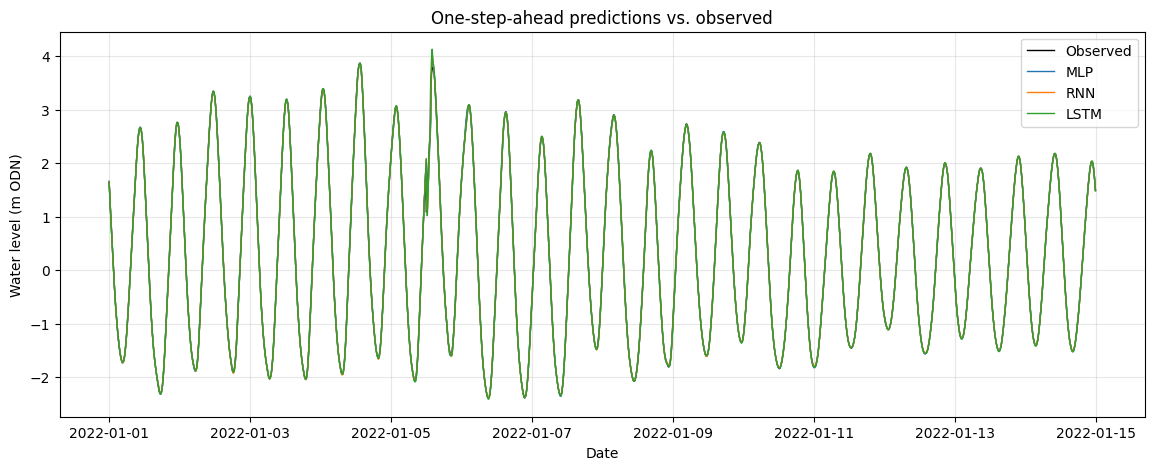

In [40]:
window_start = pd.Timestamp('2022-01-01')
window_end = window_start + pd.Timedelta(days=14)
plot_mask = (time_test >= np.datetime64(window_start)) & (time_test < np.datetime64(window_end))

plt.figure(figsize=(14, 5))
plt.plot(time_test[plot_mask], y_test[plot_mask], label='Observed', color='black', linewidth=1)
for name, preds_m in test_preds.items():
    plt.plot(time_test[plot_mask], preds_m[plot_mask], label=name, linewidth=1)
plt.xlabel('Date')
plt.ylabel('Water level (m ODN)')
plt.title('One-step-ahead predictions vs. observed')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 13. Recursive multi-horizon rollout

The models above were trained for a single 10-minute step. Feeding each model's own prediction back in as input lets us see how far the error grows at longer horizons (1h, 6h, 24h, 48h) -- a fuller picture of "prediction" than the 10-minute number alone. UTide is included too, reusing the `coef` fitted on train+val in section 6b -- since it's a fixed function of wall-clock time rather than an autoregressive model, its error doesn't grow with horizon the way the others' does, which is exactly the point of comparison here.

In [41]:
@torch.no_grad()
def recursive_rollout(model, X_start_t, horizon):
    model.eval()
    window = X_start_t.clone()
    preds = []
    for _ in range(horizon):
        pred = model(window)
        preds.append(pred)
        window = torch.cat([window[:, 1:], pred.unsqueeze(1)], dim=1)
    return torch.stack(preds, dim=1)


# roll out across the longest gap-free run in the test set
test_seg_id = (test_df['DateTime'].diff() > STEP).cumsum().to_numpy()
longest_seg = pd.Series(test_seg_id).value_counts().idxmax()
seg_vals = test_df.loc[test_seg_id == longest_seg, 'Observed_ODN'].to_numpy(dtype=np.float32)
seg_times = test_df.loc[test_seg_id == longest_seg, 'DateTime'].to_numpy()

ROLLOUT_HORIZON = 288  # 48h ahead
START_STRIDE = 144  # a fresh rollout start every 24h

starts = np.arange(LOOKBACK, len(seg_vals) - ROLLOUT_HORIZON, START_STRIDE)
X_roll = np.stack([seg_vals[s - LOOKBACK:s] for s in starts])
Y_roll = np.stack([seg_vals[s:s + ROLLOUT_HORIZON] for s in starts])
X_roll_t = to_tensor((X_roll - train_mean) / train_std)

horizons_steps = {'10min': 1, '1h': 6, '6h': 36, '24h': 144, '48h': 288}
rollout_results = []
for name, model in trained.items():
    roll_pred = recursive_rollout(model, X_roll_t, ROLLOUT_HORIZON).cpu().numpy() * train_std + train_mean
    for hname, hstep in horizons_steps.items():
        err = roll_pred[:, hstep - 1] - Y_roll[:, hstep - 1]
        rollout_results.append({'model': name, 'horizon': hname, 'rmse_m': float(np.sqrt(np.mean(err ** 2)))})

persistence_roll = np.repeat(X_roll[:, -1:], ROLLOUT_HORIZON, axis=1)
for hname, hstep in horizons_steps.items():
    err = persistence_roll[:, hstep - 1] - Y_roll[:, hstep - 1]
    rollout_results.append({'model': 'Persistence', 'horizon': hname, 'rmse_m': float(np.sqrt(np.mean(err ** 2)))})

# UTide has no lookback/autoregression -- it's a fixed function of wall-clock time, using the
# same coef fitted on train+val in section 6b. Reconstruct once over the whole segment, then
# slice out the same (start, horizon) pairs used for every other model above.
tide_seg = utide.reconstruct(pd.DatetimeIndex(seg_times), coef, verbose=False).h
utide_roll = np.stack([tide_seg[s:s + ROLLOUT_HORIZON] for s in starts])
for hname, hstep in horizons_steps.items():
    err = utide_roll[:, hstep - 1] - Y_roll[:, hstep - 1]
    rollout_results.append({'model': 'UTide', 'horizon': hname, 'rmse_m': float(np.sqrt(np.mean(err ** 2)))})

rollout_pivot = pd.DataFrame(rollout_results).pivot(index='model', columns='horizon', values='rmse_m')
rollout_pivot = rollout_pivot[list(horizons_steps.keys())]
rollout_pivot

horizon,10min,1h,6h,24h,48h
model,,,,,
LSTM,0.010718,0.061782,0.405991,0.512569,1.013570
MLP,0.011968,0.043644,0.288830,0.311286,0.388288
Persistence,0.136567,0.807679,3.070606,0.726285,1.318622
RNN,0.009139,0.060573,0.433408,0.438270,0.632270
UTide,0.237830,0.234784,0.268052,0.239187,0.239207


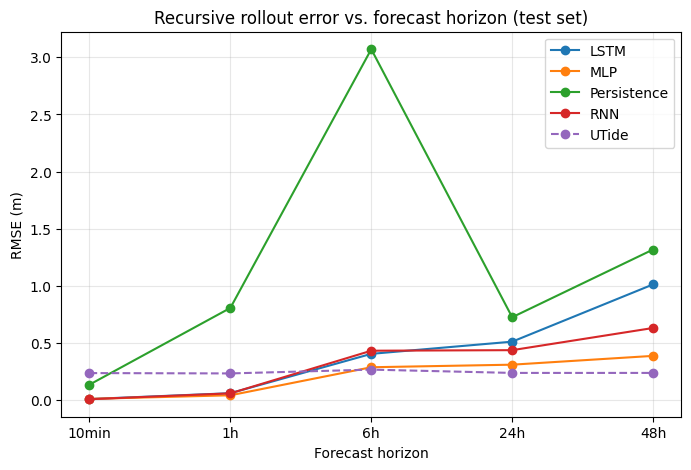

In [42]:
plt.figure(figsize=(8, 5))
for name in rollout_pivot.index:
    style = '--' if name == 'UTide' else '-'
    plt.plot(rollout_pivot.columns, rollout_pivot.loc[name], marker='o', linestyle=style, label=name)
plt.xlabel('Forecast horizon')
plt.ylabel('RMSE (m)')
plt.title('Recursive rollout error vs. forecast horizon (test set)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 14. Next steps

- Direct multi-step output heads instead of (or alongside) recursive rollout
- Add predictors beyond the gauge's own history: other Thames gauges, meteorological (wind/pressure) data
- Sweep `LOOKBACK`, hidden sizes, number of layers; try GRU
- Once the test window includes one, check performance specifically around storm surge periods